<a href="https://colab.research.google.com/github/Optimus0205/Data_Science_Project/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import re

In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
df=pd.read_csv('/content/gurgaon_properties_cleaned_v1.csv')
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,eldeco accolade,sohna road,0.87,5965.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet area: 849 sq.ft. (78.87 sq.m.),2,2,3+,study room,10.0,NaN,1 to 5 Year Old,"['Global City Centre', 'Sohna Road', 'Damdama More', 'Western Peripheral Expressway', 'GD Goenka World School', 'K.R. Mangalam University', 'Civil Hospital']",[],"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"


##Focus ->
*   areaWithType
*   additionalRoom
*   agePossession
*   furnishDetails
*   features

###areaWithType

In [ ]:
df[['area','areaWithType']].sample(5)

,area,areaWithType
437,4518.0,Plot area 502(419.74 sq.m.)
340,600.0,Super Built up area 600(55.74 sq.m.)Carpet area: 514 sq.ft. (47.75 sq.m.)
2200,1359.0,Built Up area: 1359 (126.26 sq.m.)Carpet area: 952 sq.ft. (88.44 sq.m.)
1731,3150.0,Plot area 350(292.64 sq.m.)
2846,597.0,Built Up area: 597 (55.46 sq.m.)


In [ ]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [ ]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [ ]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [ ]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [ ]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3085,1.60,flat,2120.0,Super Built up area 2120(196.95 sq.m.)Carpet area: 1450 sq.ft. (134.71 sq.m.),2120.0,NaN,1450.0
309,12.00,house,6000.0,Plot area 8000(743.22 sq.m.)Built Up area: 7000 sq.ft. (650.32 sq.m.)Carpet area: 6000 sq.ft. (557.42 sq.m.),NaN,7000.0,6000.0
1551,0.92,flat,1822.0,Super Built up area 1822(169.27 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.),1822.0,NaN,1400.0
1136,1.92,flat,2000.0,Carpet area: 2000 (185.81 sq.m.),NaN,NaN,2000.0
2637,0.72,flat,990.0,Carpet area: 990 (91.97 sq.m.),NaN,NaN,990.0


In [ ]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3354,2.40,flat,2217.0,Super Built up area 2217(205.97 sq.m.)Built Up area: 1940 sq.ft. (180.23 sq.m.)Carpet area: 1730 sq.ft. (160.72 sq.m.),2217.0,1940.0,1730.0
1558,1.91,flat,3800.0,Super Built up area 3950(366.97 sq.m.)Built Up area: 3890 sq.ft. (361.39 sq.m.)Carpet area: 3800 sq.ft. (353.03 sq.m.),3950.0,3890.0,3800.0
882,1.55,flat,1930.0,Super Built up area 1930(179.3 sq.m.)Built Up area: 1900 sq.ft. (176.52 sq.m.)Carpet area: 1350 sq.ft. (125.42 sq.m.),1930.0,1900.0,1350.0
2026,0.78,flat,1245.0,Super Built up area 1245(115.66 sq.m.)Built Up area: 850 sq.ft. (78.97 sq.m.)Carpet area: 790 sq.ft. (73.39 sq.m.),1245.0,850.0,790.0


In [ ]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(517, 7)

In [ ]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
5,1.20,house,900.0,Plot area 900(83.61 sq.m.),NaN,NaN,NaN
9,9.25,house,2340.0,Plot area 265(221.57 sq.m.)Built Up area: 262 sq.yards (219.07 sq.m.)Carpet area: 260 sq.yards (217.39 sq.m.),NaN,262.0,260.0
11,10.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
14,NaN,house,NaN,Plot area 240(200.67 sq.m.),NaN,NaN,NaN
26,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,NaN,NaN


In [ ]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(682, 7)

In [ ]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,18
price_per_sqft,18
area,18
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [ ]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
5,1.20,house,900.0,Plot area 900(83.61 sq.m.),NaN,NaN,NaN
11,10.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
14,NaN,house,NaN,Plot area 240(200.67 sq.m.),NaN,NaN,NaN
26,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,NaN,NaN
41,6.75,house,2088.0,Plot area 232(193.98 sq.m.),NaN,NaN,NaN


In [ ]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [ ]:
# all_nan values are mostky in plot area so now extractiong it
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [ ]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [ ]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
5,1.20,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.00,NaN
11,10.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,300.00,NaN
14,NaN,house,NaN,Plot area 240(200.67 sq.m.),NaN,240.00,NaN
26,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,161.00,NaN
41,6.75,house,2088.0,Plot area 232(193.98 sq.m.),NaN,232.00,NaN
54,9.54,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
60,8.00,house,3600.0,Plot area 400(334.45 sq.m.),NaN,400.00,NaN
62,4.50,house,1350.0,Plot area 150(125.42 sq.m.),NaN,150.00,NaN
71,1.95,house,1440.0,Plot area 160(133.78 sq.m.),NaN,160.00,NaN
73,7.00,house,1783.0,Plot area 1782.72(165.62 sq.m.),NaN,1782.72,NaN


In [ ]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [ ]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [ ]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
5,1.20,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.00,NaN
11,10.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.00,NaN
14,NaN,house,NaN,Plot area 240(200.67 sq.m.),NaN,240.00,NaN
26,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,1449.00,NaN
41,6.75,house,2088.0,Plot area 232(193.98 sq.m.),NaN,2088.00,NaN
54,9.54,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
60,8.00,house,3600.0,Plot area 400(334.45 sq.m.),NaN,3600.00,NaN
62,4.50,house,1350.0,Plot area 150(125.42 sq.m.),NaN,1350.00,NaN
71,1.95,house,1440.0,Plot area 160(133.78 sq.m.),NaN,1440.00,NaN
73,7.00,house,1783.0,Plot area 1782.72(165.62 sq.m.),NaN,1782.72,NaN


In [ ]:
# update the original dataframe
df.update(all_nan_df)

In [ ]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,18
price_per_sqft,18
area,18
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [ ]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,flat,eldeco accolade,sohna road,0.87,5965.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet area: 849 sq.ft. (78.87 sq.m.),2,2,3+,study room,10.0,NaN,1 to 5 Year Old,"['Global City Centre', 'Sohna Road', 'Damdama More', 'Western Peripheral Expressway', 'GD Goenka World School', 'K.R. Mangalam University', 'Civil Hospital']",[],"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']",1457.0,NaN,849.00
1,flat,tulip violet,sector 69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,not available,0.0,South-East,1 to 5 Year Old,"['Airia Mall Sector 68', 'Southern Peripheral Road', 'Golf Course Extension Rd', 'Imperio School', 'DPG Institute of Technology', 'Ektaa Hospitals', 'Indira Gandhi International Airport', 'Vipul Trade Business Centre', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']","['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2087.0,NaN,NaN
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,servant room,10.0,NaN,5 to 10 Year Old,"['Rajiv Chowk Mosque', 'Standard chartered ATM', 'Icici bank ATM', 'Samvit Health Care', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Park Hospital Gurgaon', 'Neelkanth Health Care', 'Best Urologist Atcomplete Family Clinic', 'Vishesh Dental', 'Sukhmani Hospital Pvt. Ltd', 'Wellness Eye Centre', 'Dr. Aruna Kalra', 'Medanta', 'Dr. Anuj Sharma', 'Dr. Naresh Pandita', 'Meher Clinic', 'Bones Clinic - Orthopaedics', 'Skin Clinic', 'Airforce Hospital', 'Divine Look Clinic Centre', 'Dispencery', 'Wembley estate club', 'Apollo Pharmacy', 'Gardian Pharmacy', 'Genius', 'India Oil', 'SRS Cinemas', 'SRS Cinemas', 'Hdfc bank', 'Icici bank', 'Hdfc bank', 'Haldiram', 'KFC', ""Domino's Pizza"", ""Nirula's"", 'India', 'Nook', 'Starbucks', 'Delhi Public School Primary Section', 'Kendriya Vidyalaya No.2 Sohna Road', 'CR Model Public School', 'Manav Rachna School', 'Kamla International', 'Manav Rachna Swimming Pool']","['3 Wardrobe', '6 Fan', '3 Geyser', '15 Light', '5 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Recently Renovated', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",2086.0,NaN,N

### additionalRoom

In [ ]:
df['additionalRoom'].value_counts()

,count
additionalRoom,
not available,1370
servant room,676
study room,225
others,202
pooja room,162
store room,98
"study room,servant room",92
"pooja room,servant room",81
"pooja room,study room,servant room,store room",72


In [ ]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [ ]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
3220,servant room,0,1,0,0,0
3422,"study room,pooja room,store room",1,0,1,1,0
2140,servant room,0,1,0,0,0
1545,store room,0,0,1,0,0
2545,study room,1,0,0,0,0


In [ ]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,eldeco accolade,sohna road,0.87,5965.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet area: 849 sq.ft. (78.87 sq.m.),2,2,3+,study room,10.0,NaN,1 to 5 Year Old,"['Global City Centre', 'Sohna Road', 'Damdama More', 'Western Peripheral Expressway', 'GD Goenka World School', 'K.R. Mangalam University', 'Civil Hospital']",[],"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']",1457.0,NaN,849.00,1,0,0,0,0
1,flat,tulip violet,sector 69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,not available,0.0,South-East,1 to 5 Year Old,"['Airia Mall Sector 68', 'Southern Peripheral Road', 'Golf Course Extension Rd', 'Imperio School', 'DPG Institute of Technology', 'Ektaa Hospitals', 'Indira Gandhi International Airport', 'Vipul Trade Business Centre', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']","['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2087.0,NaN,NaN,0,0,0,0,0
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,servant room,10.0,NaN,5 to 10 Year Old,"['Rajiv Chowk Mosque', 'Standard chartered ATM', 'Icici bank ATM', 'Samvit Health Care', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Park Hospital Gurgaon', 'Neelkanth Health Care', 'Best Urologist Atcomplete Family Clinic', 'Vishesh Dental', 'Sukhmani Hospital Pvt. Ltd', 'Wellness Eye Centre', 'Dr. Aruna Kalra', 'Medanta', 'Dr. Anuj Sharma', 'Dr. Naresh Pandita', 'Meher Clinic', 'Bones Clinic - Orthopaedics', 'Skin Clinic', 'Airforce Hospital', 'Divine Look Clinic Centre', 'Dispencery', 'Wembley estate club', 'Apollo Pharmacy', 'Gardian Pharmacy', 'Genius', 'India Oil', 'SRS Cinemas', 'SRS Cinemas', 'Hdfc bank', 'Icici bank', 'Hdfc bank', 'Haldiram', 'KFC', ""Domino's Pizza"", ""Nirula's"", 'India', 'Nook', 'Starbucks', 'Delhi Public School Primary Section', 'Kendriya Vidyalaya No.2 Sohna Road', 'CR Model Public School', 'Manav Rachna School', 'Kamla International', 'Manav Rachna Swimming Pool']","['3 Wardrobe', '6 Fan', '3 Geyser', '15 Light', '5 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Recently Renovated', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting'

### agePossession

In [36]:
df['agePossession'].value_counts()

,count
agePossession,
1 to 5 Year Old,1599
5 to 10 Year Old,543
0 to 1 Year Old,452
undefined,294
10+ Year Old,290
Within 6 months,59
Under Construction,47
Within 3 months,24
23-Dec,17


In [37]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [38]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [39]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1599
Moderately Old,543
New Property,535
Undefined,421
Old Property,290
Under Construction,84


In [40]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,eldeco accolade,sohna road,0.87,5965.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet area: 849 sq.ft. (78.87 sq.m.),2,2,3+,study room,10.0,NaN,Relatively New,"['Global City Centre', 'Sohna Road', 'Damdama More', 'Western Peripheral Expressway', 'GD Goenka World School', 'K.R. Mangalam University', 'Civil Hospital']",[],"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']",1457.0,NaN,849.00,1,0,0,0,0
1,flat,tulip violet,sector 69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,not available,0.0,South-East,Relatively New,"['Airia Mall Sector 68', 'Southern Peripheral Road', 'Golf Course Extension Rd', 'Imperio School', 'DPG Institute of Technology', 'Ektaa Hospitals', 'Indira Gandhi International Airport', 'Vipul Trade Business Centre', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']","['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2087.0,NaN,NaN,0,0,0,0,0
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,servant room,10.0,NaN,Moderately Old,"['Rajiv Chowk Mosque', 'Standard chartered ATM', 'Icici bank ATM', 'Samvit Health Care', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Park Hospital Gurgaon', 'Neelkanth Health Care', 'Best Urologist Atcomplete Family Clinic', 'Vishesh Dental', 'Sukhmani Hospital Pvt. Ltd', 'Wellness Eye Centre', 'Dr. Aruna Kalra', 'Medanta', 'Dr. Anuj Sharma', 'Dr. Naresh Pandita', 'Meher Clinic', 'Bones Clinic - Orthopaedics', 'Skin Clinic', 'Airforce Hospital', 'Divine Look Clinic Centre', 'Dispencery', 'Wembley estate club', 'Apollo Pharmacy', 'Gardian Pharmacy', 'Genius', 'India Oil', 'SRS Cinemas', 'SRS Cinemas', 'Hdfc bank', 'Icici bank', 'Hdfc bank', 'Haldiram', 'KFC', ""Domino's Pizza"", ""Nirula's"", 'India', 'Nook', 'Starbucks', 'Delhi Public School Primary Section', 'Kendriya Vidyalaya No.2 Sohna Road', 'CR Model Public School', 'Manav Rachna School', 'Kamla International', 'Manav Rachna Swimming Pool']","['3 Wardrobe', '6 Fan', '3 Geyser', '15 Light', '5 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Recently Renovated', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'C

###furnishDetails

In [42]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
2039,"['3 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Water Storage', 'Visitor Parking', 'Waste Disposal']"
2971,"['6 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
3418,"['1 Water Purifier', '3 Fan', '1 Fridge', '1 Dining Table', '1 Geyser', '1 Stove', '10 Light', '1 AC', '1 Chimney', '1 Curtains', '1 Modular Kitchen', '1 TV', '2 Wardrobe', '1 Washing Machine', 'No Bed', 'No Exhaust Fan', 'No Microwave', 'No Sofa']","['Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Park', 'Natural Light']"
1925,"['1 Water Purifier', '12 Fan', '1 Exhaust Fan', '9 Geyser', '1 Stove', '26 Light', '1 Chimney', '1 Modular Kitchen', '9 TV', '1 Curtains', '9 Wardrobe', 'No AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Washing Machine']","['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM']"
2633,[],"['Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting', 'Water softening plant']"


In [43]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_7806/2445438592.py:13: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [44]:
furnishings_df.shape

(3472, 19)

In [45]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

/tmp/ipykernel_7806/114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [46]:
furnishings_df.sample(5)

,AC,Water Purifier,TV,Modular Kitchen,Washing Machine,Fan,Bed,Sofa,Exhaust Fan,Stove,Wardrobe,Light,Chimney,Microwave,Geyser,Curtains,Dining Table,Fridge
3177,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2645,3,0,0,0,0,0,0,0,0,0,3,1,1,0,0,0,0,0
53,6,0,0,1,1,7,0,0,1,1,4,10,1,1,5,0,0,1
2324,0,0,0,1,0,4,0,0,0,0,2,5,0,0,2,0,0,0
63,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [47]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [48]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [49]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

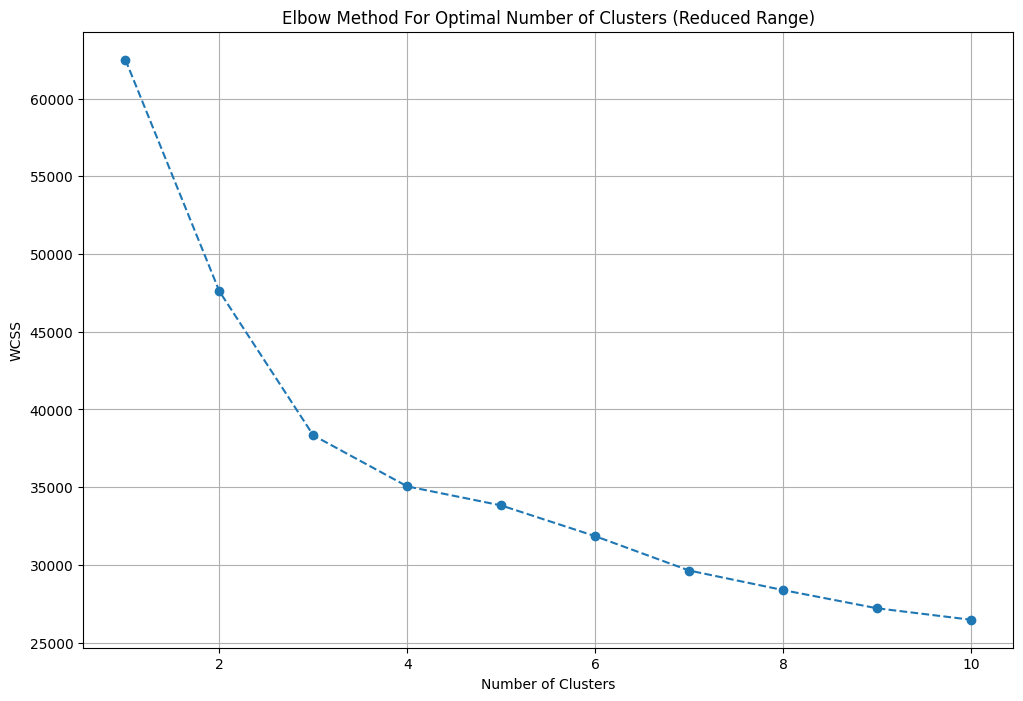

In [50]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [51]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [52]:
df = df.iloc[:,:-18]

In [53]:
df['furnishing_type'] = cluster_assignments

In [54]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
3189,"['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '4 Geyser', '1 Stove', '8 Light', '4 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']",1
2323,"['14 Bed', '14 Wardrobe', '1 Water Purifier', '1 Fridge', '14 AC', '14 TV', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Sofa', 'No Stove', 'No Washing Machine']",2
559,"['4 Fan', '1 Exhaust Fan', '3 Geyser', '1 Stove', '12 Light', '4 AC', '1 Chimney', '1 Curtains', '1 Modular Kitchen', '3 Wardrobe', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']",1
703,"['1 Water Purifier', '6 Fan', '1 Exhaust Fan', '1 Dining Table', '1 Geyser', '1 Stove', '12 Light', '1 AC', '1 Chimney', '1 Curtains', '1 Bed', '4 Wardrobe', '1 Sofa', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No TV', 'No Washing Machine']",2
3089,[],0


### features


In [60]:
df[['society','features']].sample(5)

,society,features
1396,godrej,NaN
1668,whiteland the aspen,NaN
2961,emaar emerald hills,"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
2945,independent,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM', 'Club house / Community Center']"
1064,independent,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking', 'Waste Disposal', 'Rain Water Harvesting']"


In [56]:
df['features'].isnull().sum()

np.int64(543)

In [61]:
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [63]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [64]:
temp_df = df[df['features'].isnull()]

In [65]:
temp_df.shape

(543, 26)

In [68]:
temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')[['features','TopFacilities']]

,features,TopFacilities
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,"['Swimming Pool', 'Lounge', 'Bar/Chill-Out Lounge', 'ATM', 'Aerobics Centre', 'Restaurant', 'Sauna', 'Spa', 'Skating Rink']"
6,NaN,"['Swimming Pool', 'Reading Lounge', 'Reflexology Park', 'Golf Course', 'Aerobics Centre', 'Sauna', 'Jacuzzi', 'Steam Room', 'Creche/Day care']"
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


In [66]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [69]:
df.loc[temp_df.index,'features'] = x.values

In [70]:
df['features'].isnull().sum()

np.int64(416)

In [71]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [72]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [73]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0
1584,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1552,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
666,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
1407,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0


In [74]:
features_binary_df.shape

(3472, 129)

In [75]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

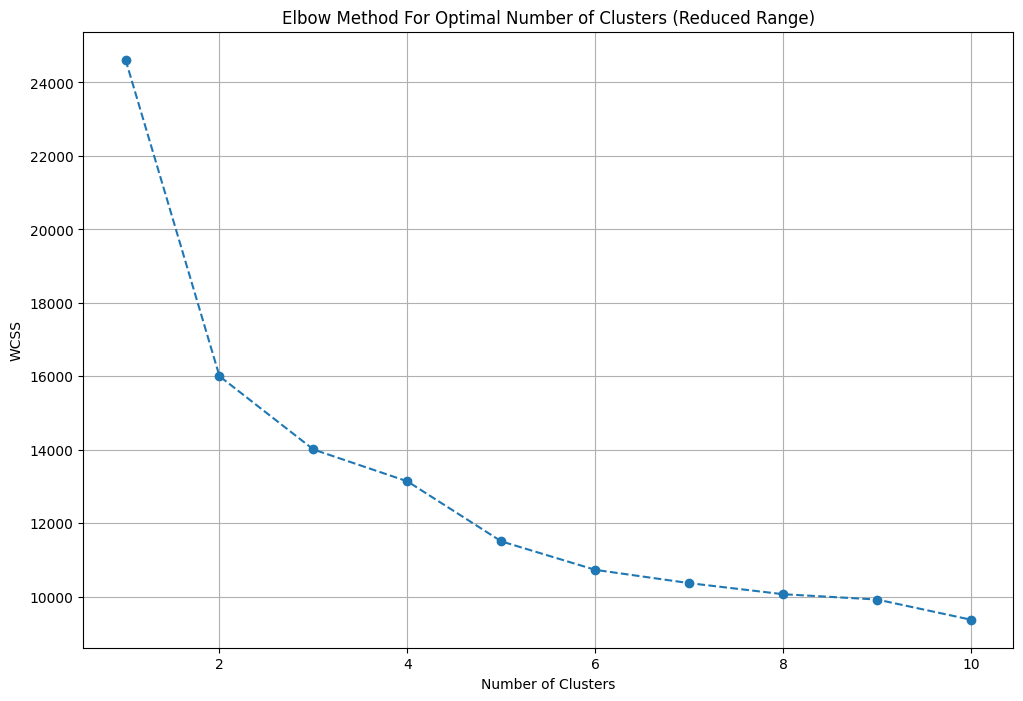

In [76]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [78]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    #'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [79]:
df['luxury_score'] = luxury_score

In [80]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,eldeco accolade,sohna road,0.87,5965.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet area: 849 sq.ft. (78.87 sq.m.),2,2,3+,study room,10.0,NaN,Relatively New,"['Global City Centre', 'Sohna Road', 'Damdama More', 'Western Peripheral Expressway', 'GD Goenka World School', 'K.R. Mangalam University', 'Civil Hospital']",[],"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']",1457.0,NaN,849.00,1,0,0,0,0,0,"[Power Back-up, Feng Shui / Vaastu Compliant, Intercom Facility, Lift(s), Maintenance Staff, Swimming Pool, Park, Security Personnel, Internet/wi-fi connectivity, Shopping Centre, Fitness Centre / GYM, Rain Water Harvesting, Club house / Community Center]",72
1,flat,tulip violet,sector 69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,not available,0.0,South-East,Relatively New,"['Airia Mall Sector 68', 'Southern Peripheral Road', 'Golf Course Extension Rd', 'Imperio School', 'DPG Institute of Technology', 'Ektaa Hospitals', 'Indira Gandhi International Airport', 'Vipul Trade Business Centre', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']","['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2087.0,NaN,NaN,0,0,0,0,0,0,"[Water purifier, Security / Fire Alarm, Power Back-up, Feng Shui / Vaastu Compliant, Private Garden / Terrace, Intercom Facility, Lift(s), High Ceiling Height, Maintenance Staff, False Ceiling Lighting, Water Storage, No open drainage around, Bank Attached Property, Piped-gas, Internet/wi-fi connectivity, Recently Renovated, Visitor Parking, Swimming Pool, Park, Security Personnel, Natural Light, Airy Rooms, Spacious Interiors, Low Density Society, Waste Disposal, Rain Water Harvesting, Water softening plant, Shopping Centre, Fitness Centre / GYM, Club house / Community Center]",157
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,servant room,10.0,NaN,Moderately Old,"['Rajiv Chowk Mosque', 'Standard chartered ATM', 'Icici bank ATM', 'Samvit Health Care', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Park Hospital Gurgaon', 'Neelkanth Health Care', 'Best Urologist Atcomplete Family Clinic', 'Vishesh Dental', 'Sukhmani Hospital Pvt. Ltd', 'Wellness Eye Centre', 'Dr. Aruna Kalra', 'Medanta', 'Dr. Anuj Sharma', 'Dr. Naresh Pandita', 'Meher Clinic', 'Bones Clinic - Orthopaedics', 'Skin Clinic', 'Airforce Hospital', 'Divine Look Clinic Centre', 'Dispencery', 'Wembley estate club', 'Apollo Pharmacy', 'Gardian Pharmacy', 'Genius', 'India Oil', 'SRS Cinemas', 'SRS Cinemas', 'Hdfc bank', 'Icici bank', 'Hdfc bank', 'Haldiram', 'KFC', ""Domino's Piz

In [81]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [82]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
386,house,independent,sector 91,3.60,14815.0,2430.0,Plot area 270(225.75 sq.m.),4,4,3,2.0,North-East,New Property,NaN,2430.0,NaN,0,0,0,0,0,1,49
682,flat,maxworth city residences,sector 10a,0.90,7083.0,1271.0,Super Built up area 1200(111.48 sq.m.),2,2,3,9.0,East,New Property,1200.0,NaN,NaN,0,0,0,0,1,0,52
1137,house,independent,sector 43,13.50,50000.0,2700.0,Plot area 300(250.84 sq.m.),16,16,3+,4.0,North-West,Relatively New,NaN,2700.0,NaN,1,1,0,1,1,0,41
1982,flat,green homes,sector 52,1.85,7872.0,2350.0,Super Built up area 2350(218.32 sq.m.),3,3,3,7.0,NaN,Moderately Old,2350.0,NaN,NaN,0,1,0,0,0,0,28
3194,flat,vatika sovereign next sector-82 a gurgaon,sector 82a,2.91,6700.0,4343.0,Super Built up area 4350(404.13 sq.m.)Carpet area: 3480 sq.ft. (323.3 sq.m.),4,4,3,6.0,East,Under Construction,4350.0,NaN,3480.0,1,1,1,0,0,1,79


In [83]:
df.shape

(3472, 23)

In [84]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)